# Cross-Validation for Metamodels
## CO₂ WAG reservoir-simulation case study using published OPM Flow data

**Paper:** Lligüizaca-Dávila et al. (2026), *CO₂ WAG and SAG machine learning data-driven models in an open-source framework 
 
**Repository:** https://github.com/Silver9232/co2-wasp



### Main research question

**How should a metamodel trained on expensive reservoir simulations be validated, and what does a CV score actually allow us to claim?**

# Three take-home messages

## 1 — Training fit is not validation

> **A metamodel should be judged by predictions of simulator runs excluded from its fitting, not by how well it reproduces its training simulations.**

We will support this message using:

- Training $R^2$
- Cross-validated $Q^2$
- Out-of-fold predictions
- Predicted-vs-simulator plots
- Residual diagnostics

---

## 2 — The CV split defines the generalization claim

> **Random K-fold mainly tests interpolation inside the sampled design, whereas structured holdout can expose failure in poorly supported regions of the design space.**

We will compare:

- Random 5-fold cross-validation
- Structured regional holdout
- Distance from validation points to the nearest training simulation
- Prediction error as a function of design support

---

## 3 — CV assesses the metamodel and the DoE together

> **Space-filling designs can improve predictive reliability, but cross-validation cannot establish validity outside the simulated parameter domain.**

We will investigate:

- Latin Hypercube Sampling (LHS)
- Random sampling
- Space-filling diagnostics
- Learning curves
- Simulation-budget effects
- Cross-design validation

# Scientific scope

The published WAG dataset varies two operational controls:

$$
\mathbf{x}
=
\begin{bmatrix}
q_{\mathrm{CO_2}} \\
q_{\mathrm{water}}
\end{bmatrix}
$$

where:

- $q_{\mathrm{CO_2}}$ is the CO₂ injection rate
- $q_{\mathrm{water}}$ is the water injection rate

The metamodel input-output relation investigated in this notebook is therefore:

$$
\mathbf{x}
=
\left[
q_{\mathrm{CO_2}},
q_{\mathrm{water}}
\right]
\longrightarrow
y
$$

We use cumulative retained CO₂ as the main response:

$$
y
=
M_{\mathrm{CO_2,retained}}
$$



Conceptually, the original workflow is:

$$
\left(
q_{\mathrm{CO_2}},
q_{\mathrm{water}}
\right)
\longrightarrow
\text{OPM Flow reservoir simulation}
\longrightarrow
M_{\mathrm{CO_2,retained}}
$$

The metamodel replaces the expensive simulator by a fast approximation:

$$
\left(
q_{\mathrm{CO_2}},
q_{\mathrm{water}}
\right)
\longrightarrow
\hat f(\mathbf{x})
\longrightarrow
\widehat{M}_{\mathrm{CO_2,retained}}
$$


# Important note on the sample-size experiment

The public repository provides approximately 300-run WAG datasets generated using:

- Latin Hypercube Sampling
- Random sampling

Later in this notebook we investigate smaller sample sizes such as:

$$
N =
30,\;
50,\;
75,\;
100,\;
150,\;
200,\;
250,\;
300
$$

These smaller datasets are generated by repeatedly subsampling the released 300-run designs.

Therefore, this experiment asks:

> **How does metamodel predictive performance change when fewer simulator runs are available from the published design?**

It is a new cross-validation sensitivity analysis.

In [2]:

pip install numpy pandas scipy matplotlib scikit-learn jupyter

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 5.3 MB 6.0 MB/s eta 0:00:01
     |████████████████████████████████| 10.8 MB 14.9 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 1.2 MB/s  eta 0:00:01
     |████████████████████████████████| 7.8 MB 20.6 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 20.1 MB/s eta 0:00:01
     |████████████████████████████████| 508 kB 8.5 MB/s eta 0:00:01
     |████████████████████████████████| 348 kB 29.9 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 20.9 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 9.7 MB/s  eta 0:00:01
     |████████████████████████████████| 249 kB 24.8 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 6.5 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 12.3 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 26.4 MB/s eta 0:00:01
     |████████████████████


# 1. Imports and reproducibility


In [ ]:


from __future__ import annotations

from pathlib import Path
from time import perf_counter
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import qmc, spearmanr
from scipy.spatial.distance import cdist

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    KFold, RepeatedKFold, LeaveOneOut, LeaveOneGroupOut, GridSearchCV
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
N_REPEATS = 20 

ROOT = Path.cwd()
DATA_DIR = ROOT / "data_cv_metamodel"
FIG_DIR = ROOT / "figures_cv_metamodel_real"
RESULT_DIR = ROOT / "results_cv_metamodel_real"

for folder in [DATA_DIR, FIG_DIR, RESULT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


# 2. Load the published WAG simulation datasets


In [5]:


DATA_URLS = {
    "LHS": (
        "https://raw.githubusercontent.com/Silver9232/co2-wasp/main/data/"
        "co2eor_lhs_seed-7_simulation_results.csv"
    ),
    "Random": (
        "https://raw.githubusercontent.com/Silver9232/co2-wasp/main/data/"
        "co2eor_random_seed-7_simulation_results.csv"
    ),
}

FILENAMES = {
    "LHS": "co2eor_lhs_seed-7_simulation_results.csv",
    "Random": "co2eor_random_seed-7_simulation_results.csv",
}

def load_dataset(label):
    # Offline-first: use cached/local CSV if present.
    candidates = [
        DATA_DIR / FILENAMES[label],
        ROOT / FILENAMES[label],
    ]
    for path in candidates:
        if path.exists():
            print(f"{label}: loading {path}")
            return pd.read_csv(path)

    # Online fallback.
    print(f"{label}: downloading from GitHub")
    df = pd.read_csv(DATA_URLS[label])
    df.to_csv(DATA_DIR / FILENAMES[label], index=False)
    return df

lhs_raw = load_dataset("LHS")
random_raw = load_dataset("Random")

print("LHS shape   :", lhs_raw.shape)
print("Random shape:", random_raw.shape)

LHS: downloading from GitHub
Random: downloading from GitHub
LHS shape   : (300, 14)
Random shape: (300, 14)


In [8]:
lhs_raw.head()

,Gas Injection Rate (GRATES),Water Injection Rate (WRATES),oil_pro_vol,wat_inj_vol,wat_pro_vol,gas_inj_vol,gas_pro_vol,gas_retained,co2_injected,co2_backprod,co2_retained,prod_bhp,inj_bhp,ratio_oil_to_inj_vol
0,4242.695211,6131.563537,11096293.0,11190103.0,158469.156250,7742919.0,11411339.0,-3668420.0,7742922.50,5055381.500,2687541.000,2400.0,0.0,0.586081
1,4672.115318,12437.705829,19044558.0,22698814.0,473110.093750,8526610.0,16690940.0,-8164330.0,8526624.00,5782219.000,2744405.000,2400.0,0.0,0.609906
2,1443.608804,12594.361297,18525788.0,22984710.0,496855.781250,2634586.0,11807105.0,-9172519.0,2634629.00,1195538.625,1439090.375,2400.0,0.0,0.723119
3,3825.489435,5042.299125,9658610.0,9202196.0,142257.156250,6981518.0,9783874.0,-2802356.0,6981506.00,4251421.500,2730084.500,2400.0,0.0,0.596810
4,1359.190391,10456.356412,16065234.0,19082850.0,217374.328125,2480522.5,10370985.0,-7890462.5,2480531.25,1168818.500,1311712.750,2400.0,0.0,0.745024


In [11]:
random_raw.head()

,Gas Injection Rate (GRATES),Water Injection Rate (WRATES),oil_pro_vol,wat_inj_vol,wat_pro_vol,gas_inj_vol,gas_pro_vol,gas_retained,co2_injected,co2_backprod,co2_retained,prod_bhp,inj_bhp,ratio_oil_to_inj_vol
0,1305.233157,14381.348210,18948412.0,25954656.0,2.427910e+06,2382050.5,11731981.0,-9349930.5,2382068.75,878328.125,1503740.625,2400.0,0.0,0.668688
1,4119.675169,9697.126947,15706077.0,17697256.0,2.096735e+05,7518407.0,14106249.0,-6587842.0,7518398.50,5109814.000,2408584.500,2400.0,0.0,0.622870
2,2753.636926,5056.419539,9389887.0,9227966.0,1.389825e+05,5025387.5,8120734.0,-3095346.5,5025393.50,2742207.500,2283186.000,2400.0,0.0,0.658784
3,3893.860711,14992.083014,19566632.0,26676796.0,3.261526e+06,7106296.0,15290559.0,-8184263.0,7106263.00,4082795.750,3023467.250,2400.0,0.0,0.579184
4,4911.958048,5477.732127,10441852.0,9996861.0,1.516091e+05,8964323.0,11905220.0,-2940897.0,8964314.00,5924127.000,3040187.000,2400.0,0.0,0.550696


# 3. Define the metamodel problem

In [12]:


FEATURES = [
    "Gas Injection Rate (GRATES)",
    "Water Injection Rate (WRATES)",
]
TARGET = "co2_retained"

#  geometry normalization.
DOMAIN_LOWER = np.array([1000.0, 5000.0])
DOMAIN_UPPER = np.array([5000.0, 15000.0])

def xy(df):
    return (
        df[FEATURES].to_numpy(float),
        df[TARGET].to_numpy(float),
    )

def normalize_domain(X):
    return (X - DOMAIN_LOWER) / (DOMAIN_UPPER - DOMAIN_LOWER)

X_lhs, y_lhs = xy(lhs_raw)
X_random, y_random = xy(random_raw)
Xn_lhs = normalize_domain(X_lhs)
Xn_random = normalize_domain(X_random)

pd.DataFrame({
    "Dataset": ["LHS", "Random"],
    "N": [len(y_lhs), len(y_random)],
    "Gas min": [X_lhs[:,0].min(), X_random[:,0].min()],
    "Gas max": [X_lhs[:,0].max(), X_random[:,0].max()],
    "Water min": [X_lhs[:,1].min(), X_random[:,1].min()],
    "Water max": [X_lhs[:,1].max(), X_random[:,1].max()],
    "CO2 retained min": [y_lhs.min(), y_random.min()],
    "CO2 retained max": [y_lhs.max(), y_random.max()],
})

,Dataset,N,Gas min,Gas max,Water min,Water max,CO2 retained min,CO2 retained max
0,LHS,300,1002.347904,4987.752099,5019.376212,14993.262758,1.118707e+06,3313094.0
1,Random,300,1005.707522,4970.230877,5042.603777,14992.083014,1.101304e+06,3314584.0


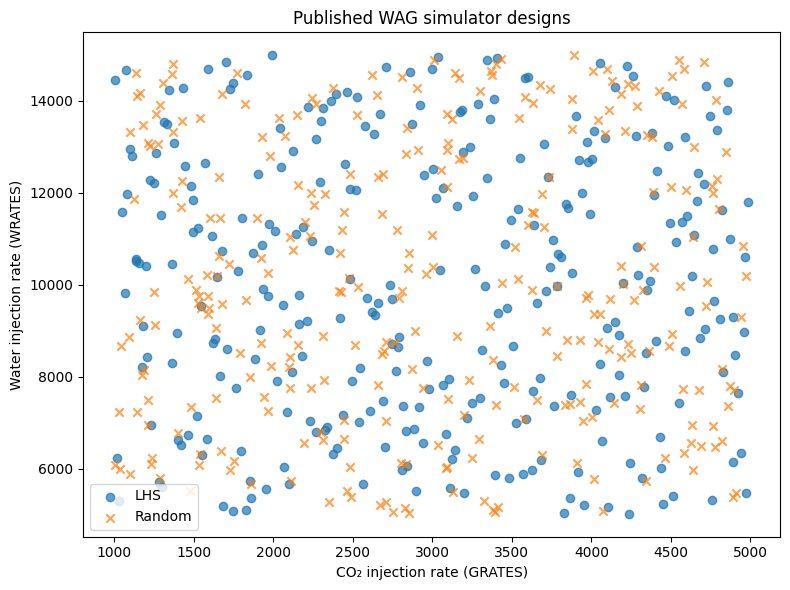

In [13]:

plt.figure(figsize=(8, 6))
plt.scatter(X_lhs[:,0], X_lhs[:,1], alpha=0.7, label="LHS")
plt.scatter(X_random[:,0], X_random[:,1], marker="x", alpha=0.7, label="Random")
plt.xlabel("CO₂ injection rate (GRATES)")
plt.ylabel("Water injection rate (WRATES)")
plt.title("Published WAG simulator designs")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_lhs_vs_random_designs.png", dpi=300)
plt.show()

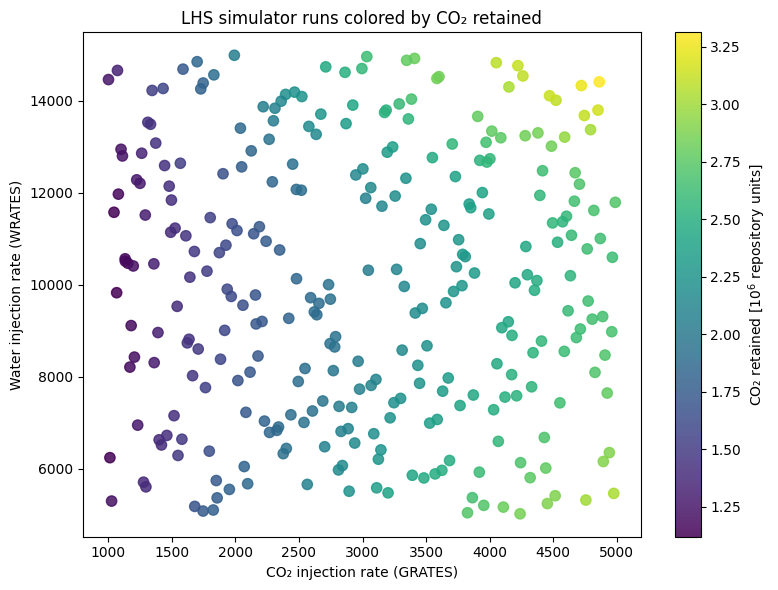

In [14]:


plt.figure(figsize=(8, 6))
sc = plt.scatter(
    X_lhs[:,0], X_lhs[:,1],
    c=y_lhs/1e6, s=55, alpha=0.85
)
plt.xlabel("CO₂ injection rate (GRATES)")
plt.ylabel("Water injection rate (WRATES)")
plt.title("LHS simulator runs colored by CO₂ retained")
cb = plt.colorbar(sc)
cb.set_label("CO₂ retained [$10^6$ repository units]")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_lhs_response.png", dpi=300)
plt.show()

# Candidate metamodels

We compare three conceptually different surrogate models.

## Quadratic response surface

A classical DoE-based metamodel:

$$
\hat y
=
\beta_0
+\beta_1x_1
+\beta_2x_2
+\beta_{11}x_1^2
+\beta_{22}x_2^2
+\beta_{12}x_1x_2
$$

**Role:** simple and interpretable baseline directly connected to response-surface methodology.

## Gradient boosting regressor

A flexible nonlinear machine-learning metamodel built by sequentially combining weak regression trees.

**Role:** tests whether a more flexible nonlinear surrogate improves predictive performance.

## Gaussian process

A probabilistic surrogate model commonly used for computer experiments.

**Role:** provides a smooth nonlinear metamodel and can also quantify predictive uncertainty.

# 4. Define candidate metamodels

In [30]:

quadratic_rsm = Pipeline([
    ("scale", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge", Ridge(alpha=1e-8)),
])



gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=2,
    subsample=0.9,
    random_state=SEED,
)

gp_kernel = (
    ConstantKernel(1.0, (1e-2, 1e2))
    * Matern(length_scale=np.ones(2), length_scale_bounds=(1e-2,1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10,1e-2))
)

gp = Pipeline([
    ("scale", StandardScaler()),
    ("gp", GaussianProcessRegressor(
        kernel=gp_kernel,
        normalize_y=True,
        n_restarts_optimizer=0 if QUICK_RUN else 2,
        random_state=SEED,
    )),
])

MODELS_MAIN = {
    "Quadratic RSM": quadratic_rsm,
    "GBR": gbr,
    "Gaussian Process": gp
}

# 5 . Validation metrics

We use two main metrics.

## RMSE

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(
y_i-\hat y_i
\right)^2
}
$$
starrr
RMSE measures the typical prediction error in the same units as the simulator response.

Lower is better.

---

## Predictive $Q^2$

For cross-validated predictions:

$$
Q^2
=
1-
\frac{
\sum_{i=1}^{N}
\left(
y_i-\hat y_i^{CV}
\right)^2
}{
\sum_{i=1}^{N}
\left(
y_i-\bar y
\right)^2
}
$$

Interpretation:

- $Q^2 \rightarrow 1$: strong predictive performance
- $Q^2 \approx 0$: little improvement over predicting the mean
- $Q^2 < 0$: poor predictive performance


In [18]:
def rmse(y_true, y_pred):
    return np.sqrt(
        mean_squared_error(y_true, y_pred)
    )


def q2_score(y_true, y_pred):
    press = np.sum(
        (y_true - y_pred) ** 2
    )

    tss = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    return 1 - press / tss

# 6. Explicit out-of-fold prediction function

In [19]:


def make_oof_predictions(model, X, y, splitter, groups=None):
    """
    Create exactly one validation prediction for each observation.

    This explicit implementation is useful pedagogically because it
    makes the train/validation separation visible and also works with
    group-based splitters.
    """
    X = np.asarray(X)
    y = np.asarray(y)

    pred = np.full(len(y), np.nan, dtype=float)
    fold_id = np.full(len(y), -1, dtype=int)

    if groups is None:
        iterator = splitter.split(X, y)
    else:
        iterator = splitter.split(X, y, groups)

    for fold, (train_idx, val_idx) in enumerate(iterator):
        fitted = clone(model)
        fitted.fit(X[train_idx], y[train_idx])
        pred[val_idx] = fitted.predict(X[val_idx])
        fold_id[val_idx] = fold

    if np.isnan(pred).any():
        raise RuntimeError("Some rows did not receive an OOF prediction.")

    return pred, fold_id

# TAKE-HOME MESSAGE 1
## Training fit is not predictive validation

The next visual compares:

- training \(R^2\): reproduction of already-seen simulator data
- CV \(Q^2\): prediction of excluded simulator data

A model can look nearly perfect in training and still have worse predictive performance.

# Experiment A — Standard random 5-fold cross-validation

We divide the 300 simulator runs into five folds of approximately equal size.

At each iteration:

$$
80\% \;\longrightarrow\; \text{training}
\qquad
20\% \;\longrightarrow\; \text{validation}
$$

The metamodel is fitted using four folds and evaluated on the remaining fold.

This procedure is repeated five times, so that every simulator run is used for validation exactly once.



In [31]:

kf5 = KFold(n_splits=5, shuffle=True, random_state=SEED)

baseline_rows = []
baseline_predictions = {}

for name, model in MODELS_MAIN.items():

    # Training score: model is evaluated on rows used to fit it.
    fitted = clone(model)
    fitted.fit(X_lhs, y_lhs)
    train_pred = fitted.predict(X_lhs)
    train_r2 = r2_score(
        y_lhs,
        train_pred
    )

    # CV score: each prediction comes from a model that excluded that row.
    oof_pred, fold_id = make_oof_predictions(
        model, X_lhs, y_lhs, kf5
    )

    baseline_predictions[name] = oof_pred
    cv_rmse = rmse(
        y_lhs,
        oof_pred
    )

    cv_q2 = q2_score(
        y_lhs,
        oof_pred
    )

    baseline_rows.append({

        "Model": name,

        # Training goodness-of-fit
        "Training R2": train_r2,

        # Predictive cross-validation metrics
        "CV RMSE": cv_rmse,
        "CV Q2": cv_q2
    })



baseline_table = pd.DataFrame(
    baseline_rows
)


baseline_table = (
    baseline_table
    .sort_values(
        by="CV RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)



/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-pac

In [32]:
baseline_table

,Model,Training R2,CV RMSE,CV Q2
0,Gaussian Process,0.999601,12567.443927,0.999404
1,GBR,0.997395,49940.035731,0.990585
2,Quadratic RSM,0.988425,57093.630169,0.987694


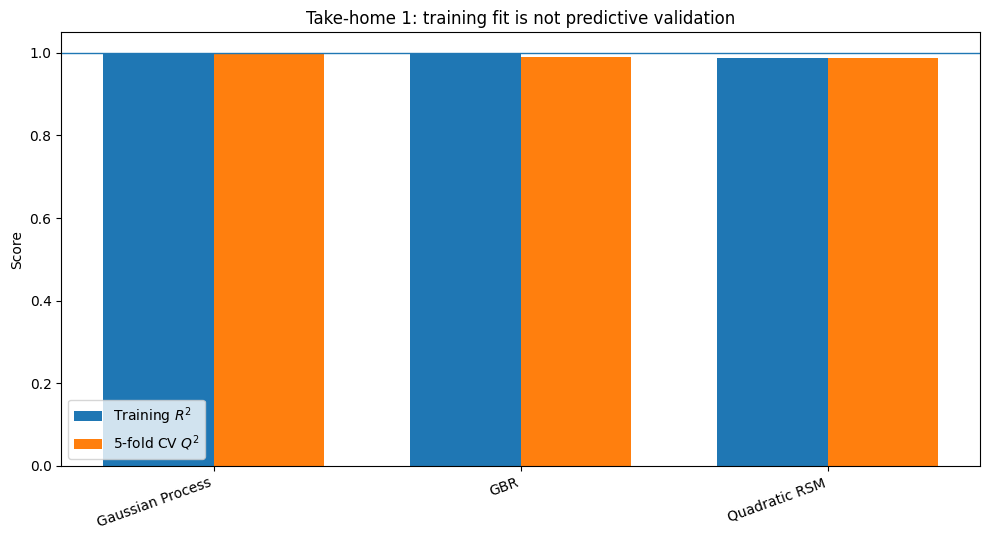

In [33]:


plot_df = baseline_table.sort_values("CV Q2", ascending=False).reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.36

plt.figure(figsize=(10,5.5))
plt.bar(x-width/2, plot_df["Training R2"], width=width, label="Training $R^2$")
plt.bar(x+width/2, plot_df["CV Q2"], width=width, label="5-fold CV $Q^2$")
plt.axhline(1.0, linewidth=1)
plt.xticks(x, plot_df["Model"], rotation=20, ha="right")
plt.ylabel("Score")
plt.title("Take-home 1: training fit is not predictive validation")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "04_message1_training_r2_vs_cv_q2.png", dpi=300)
plt.show()

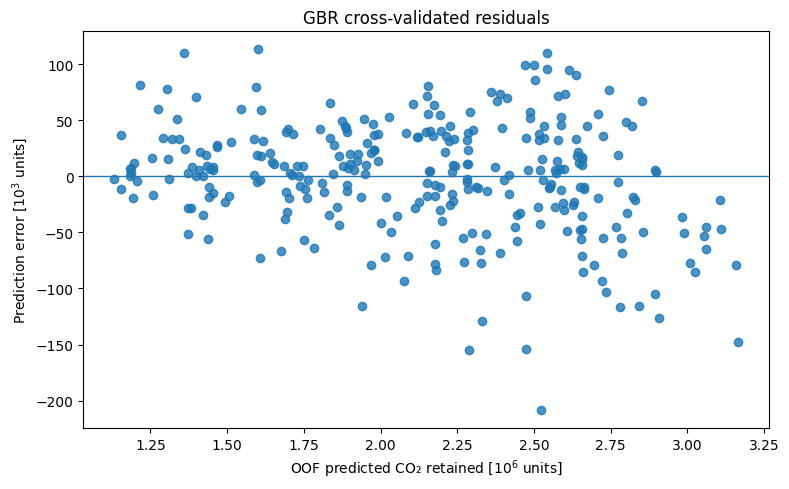

In [35]:

residual = y_oof_gbr - y_lhs

plt.figure(figsize=(8,5))
plt.scatter(y_oof_gbr/1e6, residual/1e3, alpha=0.8)
plt.axhline(0.0, linewidth=1)
plt.xlabel("OOF predicted CO₂ retained [$10^6$ units]")
plt.ylabel("Prediction error [$10^3$ units]")
plt.title("GBR cross-validated residuals")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_gbr_oof_residuals.png", dpi=300)
plt.show()



# Experiment B — Repeated 5-fold cross-validation

A single 5-fold partition may be unusually favorable or unfavorable.

To evaluate the sensitivity of the validation result to the particular data split, we repeat the 5-fold cross-validation several times using different partitions.

For example, with 20 repetitions:

$$
5 \text{-fold CV} \times 20 \text{ repetitions}
=
100 \text{ validation folds}
$$

For every fold, we calculate:

- RMSE — prediction error
- $Q^2$ — predictive performance

We then examine both the **average performance** and its **variation across different splits**.


> **A reliable metamodel should not only have low validation error, but should also give reasonably stable results across different train-validation partitions.**

In [36]:


rkf = RepeatedKFold(
    n_splits=5,
    n_repeats=N_REPEATS,
    random_state=SEED
)

def evaluate_repeated_cv(model, X, y, splitter):

    results = []

    for split_id, (train_idx, val_idx) in enumerate(
        splitter.split(X, y)
    ):
        fitted_model = clone(model)

        X_train = X[train_idx]
        y_train = y[train_idx]

        X_val = X[val_idx]
        y_val = y[val_idx]

        fitted_model.fit(
            X_train,
            y_train
        )
        y_pred = fitted_model.predict(
            X_val
        )


        fold_rmse = rmse(
            y_val,
            y_pred
        )

        fold_q2 = q2_score(
            y_val,
            y_pred
        )

        results.append({

            "Split": split_id,

            "N_train": len(train_idx),

            "N_validation": len(val_idx),

            "RMSE": fold_rmse,

            "Q2": fold_q2
        })


    return pd.DataFrame(results)

In [38]:


repeated_results = []



for name, model in MODELS_MAIN.items():

    model_results = evaluate_repeated_cv(
        model=model,
        X=X_lhs,
        y=y_lhs,
        splitter=rkf
    )

    model_results["Model"] = name

    repeated_results.append(
        model_results
    )


repeated_cv = pd.concat(
    repeated_results,
    ignore_index=True
)



/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packag

In [45]:
repeated_summary = (
    repeated_cv
    .groupby("Model")
    .agg(
        Mean_RMSE=("RMSE", "mean"),
        SD_RMSE=("RMSE", "std"),
        Mean_Q2=("Q2", "mean"),
        SD_Q2=("Q2", "std")
    )
    .sort_values(
        "Mean_RMSE"
    )
)


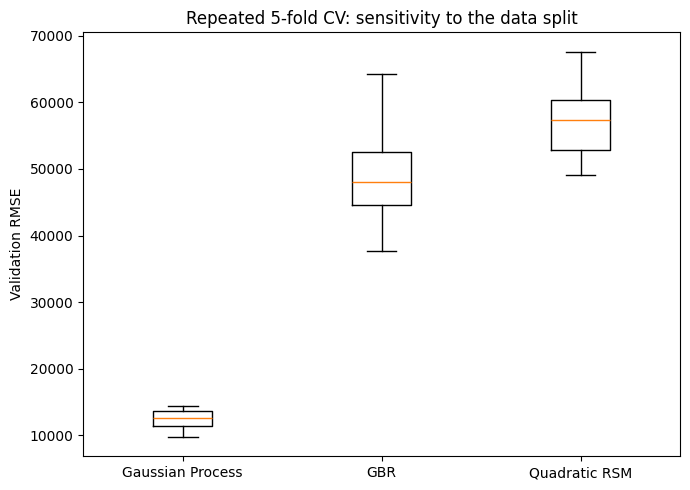

In [ ]:

model_names = list(
    repeated_summary.index
)

rmse_data = [
    repeated_cv.loc[
        repeated_cv["Model"] == name,
        "RMSE"
    ].to_numpy()

    for name in model_names
]


plt.figure(
    figsize=(7, 5)
)

plt.boxplot(
    rmse_data,
    tick_labels=model_names,
    showfliers=True
)

plt.ylabel(
    "Validation RMSE"
)

plt.title(
    "Repeated 5-fold CV: sensitivity to the data split"
)

plt.tight_layout()

plt.show()


mean q2 

# Experiment C — LOOCV versus 5-fold cross-validation

We compare two cross-validation strategies using the same reservoir-simulation dataset.

Assume we have:

$$
N = 300
$$

simulator runs.

## Leave-One-Out Cross-Validation (LOOCV)

In LOOCV, one simulation is used for validation and all remaining simulations are used for training.

Therefore:

$$
K = N = 300
$$

and in each fit:

$$
N_{\mathrm{train}} = N - 1 = 299
$$

The procedure is repeated once for every simulation.

So for each metamodel:

$$
300 \text{ model fits}
$$

are required.

---

## 5-fold cross-validation

In 5-fold CV, the dataset is divided into five folds.

At each iteration:

$$
N_{\mathrm{train}}
\approx
0.8N
=
240
$$

and

$$
N_{\mathrm{validation}}
\approx
0.2N
=
60
$$

The procedure requires only:

$$
5 \text{ model fits}
$$

per metamodel.

---

## What are we comparing?

LOOCV uses almost all available simulator runs for every model fit, but it is computationally much more expensive.

5-fold CV uses slightly less training data per fit, but requires far fewer model evaluations.

> **The objective of this experiment is to compare predictive performance and computational cost between LOOCV and 5-fold CV.**

In [46]:

LOOCV_MODELS = {
    "Quadratic RSM": quadratic_rsm,
    "GBR": gbr,
}

loocv_rows = []

for name, model in LOOCV_MODELS.items():

    t0 = perf_counter()
    pred5, _ = make_oof_predictions(
        model, X_lhs, y_lhs,
        KFold(n_splits=5, shuffle=True, random_state=SEED)
    )
    time5 = perf_counter()-t0

    loocv_rows.append({
        "Model": name,
        "Scheme": "5-fold",
        "Fits": 5,
        "RMSE": rmse(y_lhs,pred5),
        "Q2": q2_score(y_lhs,pred5),
        "Seconds": time5,
    })

    t0 = perf_counter()
    predloo, _ = make_oof_predictions(
        model, X_lhs, y_lhs, LeaveOneOut()
    )
    timeloo = perf_counter()-t0

    loocv_rows.append({
        "Model": name,
        "Scheme": "LOOCV",
        "Fits": len(y_lhs),
        "RMSE": rmse(y_lhs,predloo),
        "Q2": q2_score(y_lhs,predloo),
        "Seconds": timeloo,
    })

loocv_table = pd.DataFrame(loocv_rows)
loocv_table

,Model,Scheme,Fits,RMSE,Q2,Seconds
0,Quadratic RSM,5-fold,5,57093.630169,0.987694,0.013305
1,Quadratic RSM,LOOCV,300,57169.996917,0.987661,0.396966
2,GBR,5-fold,5,49940.035731,0.990585,0.510242
3,GBR,LOOCV,300,45672.354877,0.992125,33.331557


# TAKE-HOME MESSAGE 2
## Same data + same model + different split = different claim

### Random 5-fold asks
> Can the metamodel predict new operating points interspersed among already sampled points?

### Quadrant holdout asks
> Can the metamodel predict an operating-condition combination absent from fitting?

These are not interchangeable validation questions.

# Experiment D — Structured operating-region holdout

Random K-fold usually places validation points close to training simulations.

This mainly evaluates interpolation within an already sampled design.

To create a more demanding validation problem, we divide the operating domain using the midpoints:

$$
q_g = 3000
$$

$$
q_w = 10000
$$

This creates four operating quadrants.

We then leave one complete quadrant out at a time:

$$
\text{3 quadrants}
\rightarrow
\text{training}
$$

$$
\text{1 quadrant}
\rightarrow
\text{validation}
$$

The procedure is repeated four times so that every quadrant is used once for validation.

> **This tests whether the metamodel can predict an operating-condition region that was completely absent during fitting.**

In [47]:

GAS_MID = (DOMAIN_LOWER[0]+DOMAIN_UPPER[0])/2
WATER_MID = (DOMAIN_LOWER[1]+DOMAIN_UPPER[1])/2

def quadrant_groups(X):
    gas_high = (X[:,0] >= GAS_MID).astype(int)
    water_high = (X[:,1] >= WATER_MID).astype(int)
    # 0 low/low, 1 low/high, 2 high/low, 3 high/high
    return 2*gas_high + water_high

groups_lhs = quadrant_groups(X_lhs)
pd.Series(groups_lhs).value_counts().sort_index()

0    78
1    72
2    72
3    78
Name: count, dtype: int64

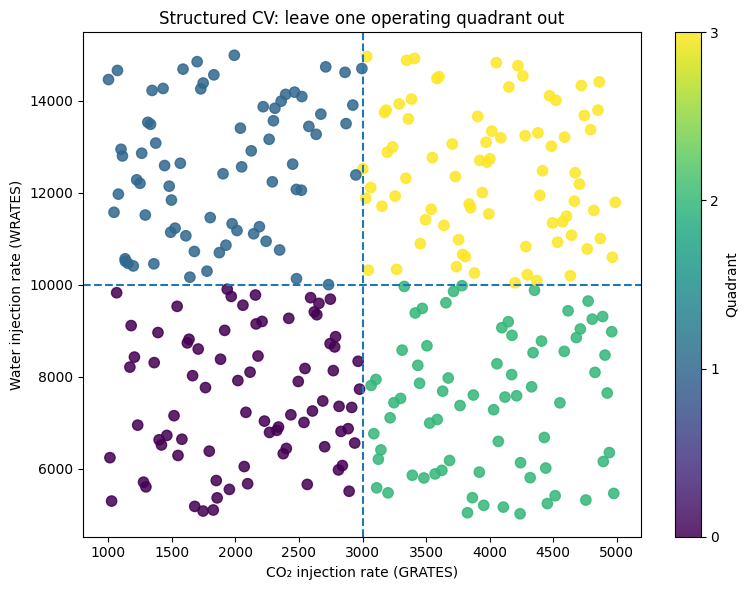

In [48]:

plt.figure(figsize=(8,6))
sc = plt.scatter(X_lhs[:,0], X_lhs[:,1], c=groups_lhs, s=55, alpha=0.85)
plt.axvline(GAS_MID, linestyle="--")
plt.axhline(WATER_MID, linestyle="--")
plt.xlabel("CO₂ injection rate (GRATES)")
plt.ylabel("Water injection rate (WRATES)")
plt.title("Structured CV: leave one operating quadrant out")
cb = plt.colorbar(sc, ticks=[0,1,2,3])
cb.set_label("Quadrant")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_quadrant_holdout_design.png", dpi=300)
plt.show()

In [50]:
random_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

regional_cv = LeaveOneGroupOut()

comparison_rows = []
split_predictions = {}

for name, model in MODELS_EXTENDED.items():

    pred_random, _ = make_oof_predictions(
        model=model,
        X=X_lhs,
        y=y_lhs,
        splitter=random_cv
    )

    pred_quadrant, _ = make_oof_predictions(
        model=model,
        X=X_lhs,
        y=y_lhs,
        splitter=regional_cv,
        groups=groups_lhs
    )

    split_predictions[
        (name, "Random 5-fold")
    ] = pred_random

    split_predictions[
        (name, "Quadrant holdout")
    ] = pred_quadrant

    comparison_rows.append({
        "Model": name,
        "CV strategy": "Random 5-fold",
        "RMSE": rmse(y_lhs, pred_random),
        "Q2": q2_score(y_lhs, pred_random)
    })

    comparison_rows.append({
        "Model": name,
        "CV strategy": "Quadrant holdout",
        "RMSE": rmse(y_lhs, pred_quadrant),
        "Q2": q2_score(y_lhs, pred_quadrant)
    })

split_comparison = pd.DataFrame(
    comparison_rows
)



/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packag

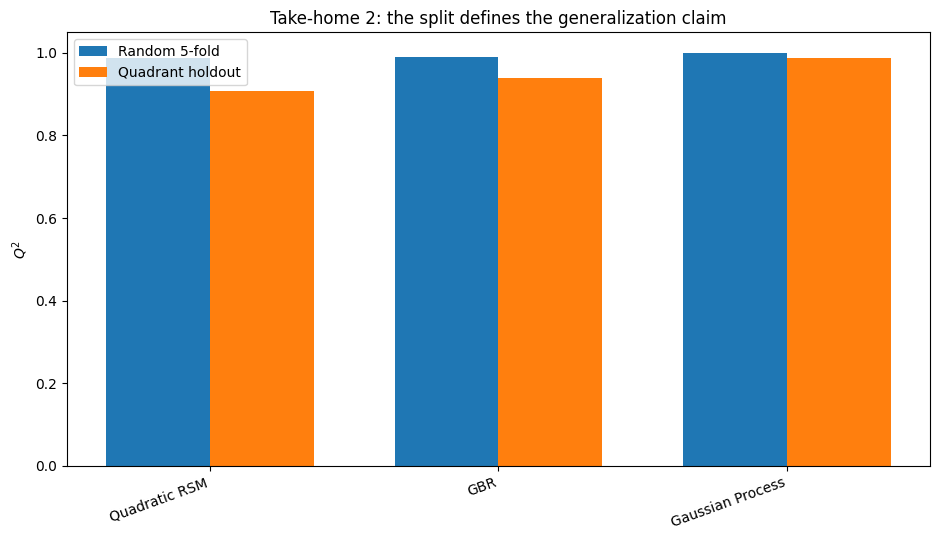

In [52]:
msg2 = (
    split_comparison
    .pivot(
        index="Model",
        columns="CV strategy",
        values="Q2"
    )
    .loc[list(MODELS_EXTENDED.keys())]
)

x = np.arange(len(msg2))
width = 0.36

plt.figure(figsize=(9.5, 5.5))

plt.bar(
    x - width / 2,
    msg2["Random 5-fold"],
    width=width,
    label="Random 5-fold"
)

plt.bar(
    x + width / 2,
    msg2["Quadrant holdout"],
    width=width,
    label="Quadrant holdout"
)

plt.xticks(
    x,
    msg2.index,
    rotation=20,
    ha="right"
)

plt.ylabel("$Q^2$")

plt.title(
    "Take-home 2: the split defines the generalization claim"
)

plt.legend()
plt.tight_layout()
plt.show()

# Why structured holdout can be harder: geometric support

For each validation point define the distance to the nearest training simulation:

\[
d_i =
\min_{\mathbf{x}_j\in\mathcal D_{\rm train}}
\left\|
\tilde{\mathbf{x}}_i-\tilde{\mathbf{x}}_j
\right\|_2
\]

where \(\tilde{\mathbf{x}}\) is normalized using the fixed operating-domain limits.

If \(d_i\) is large, the surrogate is making a prediction with weaker local support.

This provides a direct bridge between **DoE geometry** and **CV error**.

In [55]:

def oof_with_distance(model, X, y, splitter, groups=None):
    X = np.asarray(X)
    y = np.asarray(y)
    Xn = normalize_domain(X)

    records = []

    if groups is None:
        iterator = splitter.split(X, y)
    else:
        iterator = splitter.split(X, y, groups)

    for fold, (train_idx, val_idx) in enumerate(iterator):
        fitted = clone(model)
        fitted.fit(X[train_idx], y[train_idx])
        pred = fitted.predict(X[val_idx])

        # Distance in fixed normalized physical design coordinates.
        D = cdist(Xn[val_idx], Xn[train_idx])
        nearest = D.min(axis=1)

        for local_i, global_i in enumerate(val_idx):
            records.append({
                "index": global_i,
                "fold": fold,
                "y_true": y[global_i],
                "y_pred": pred[local_i],
                "abs_error": abs(pred[local_i]-y[global_i]),
                "nearest_train_distance": nearest[local_i],
            })

    return pd.DataFrame(records).sort_values("index").reset_index(drop=True)


distance_random = oof_with_distance(
    gbr, X_lhs, y_lhs,
    KFold(n_splits=5, shuffle=True, random_state=SEED)
)

distance_quadrant = oof_with_distance(
    gbr, X_lhs, y_lhs,
    LeaveOneGroupOut(),
    groups=groups_lhs
)



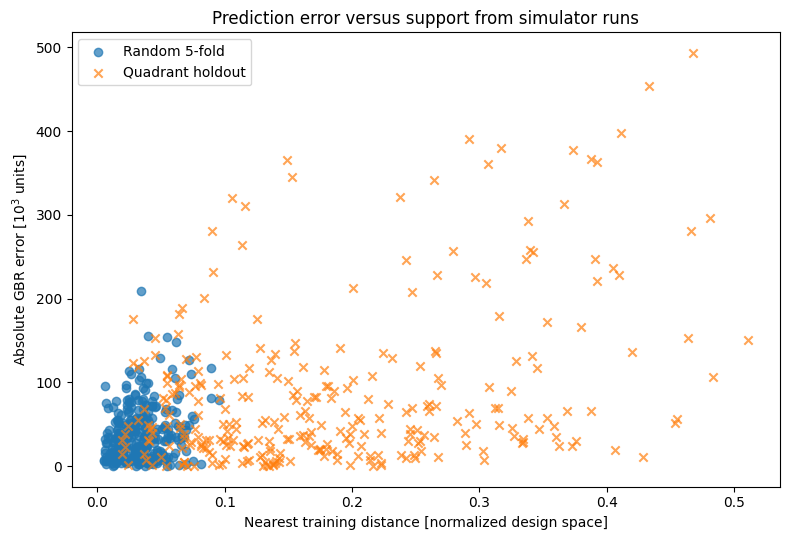

In [57]:

plt.figure(figsize=(8,5.5))
plt.scatter(
    distance_random["nearest_train_distance"],
    distance_random["abs_error"]/1e3,
    alpha=0.7,
    label="Random 5-fold"
)
plt.scatter(
    distance_quadrant["nearest_train_distance"],
    distance_quadrant["abs_error"]/1e3,
    alpha=0.7,
    marker="x",
    label="Quadrant holdout"
)
plt.xlabel("Nearest training distance [normalized design space]")
plt.ylabel("Absolute GBR error [$10^3$ units]")
plt.title("Prediction error versus support from simulator runs")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "10_message2_distance_vs_error.png", dpi=300)
plt.show()

# TAKE-HOME MESSAGE 3

## CV evaluates both the metamodel and the information provided by the DoE



Changing the sampling strategy (for example, LHS versus random sampling) changes the **geometry and coverage of that information**.
Changing $N$ changes the amount of simulator information available.

Therefore, the observed cross-validation error depends on the complete modeling workflow:

$$
\text{DoE}
+
\text{metamodel}
+
\text{validation strategy}
$$



# Experiment E — Cross-design external validation

The repository contains two independently sampled WAG simulation datasets:

- 300 simulations generated using Latin Hypercube Sampling (LHS)
- 300 simulations generated using random sampling

This allows us to perform a stronger validation test than simply splitting one dataset into training and validation folds.

## Direction A



$$
\text{Train on LHS}
\longrightarrow
\text{Test on Random}
$$

---

## Direction B



$$
\text{Train on Random}
\longrightarrow
\text{Test on LHS}
$$

---

## Why is this useful?

The test simulations are not created by partitioning the training dataset.

They come from a separately sampled experimental design.

Therefore, this gives an additional check of whether the metamodel can generalize to new simulator runs within the same operating domain.


In [58]:

external_rows = []

pairs = [
    ("LHS", X_lhs, y_lhs, "Random", X_random, y_random),
    ("Random", X_random, y_random, "LHS", X_lhs, y_lhs),
]

for train_name, Xtr, ytr, test_name, Xte, yte in pairs:

    for model_name, model in MODELS_EXTENDED.items():

        # Internal CV estimate using only the training design.
        internal_pred, _ = make_oof_predictions(
            model, Xtr, ytr,
            KFold(n_splits=5, shuffle=True, random_state=SEED)
        )

        # External test on the other independently sampled design.
        fitted = clone(model)
        fitted.fit(Xtr, ytr)
        external_pred = fitted.predict(Xte)

        external_rows.append({
            "Model": model_name,
            "Train design": train_name,
            "External test design": test_name,
            "Internal CV RMSE": rmse(ytr, internal_pred),
            "Internal CV Q2": q2_score(ytr, internal_pred),
            "External RMSE": rmse(yte, external_pred),
            "External Q2": q2_score(yte, external_pred),
        })

external_table = pd.DataFrame(external_rows)

external_table.sort_values(
    ["Train design","External RMSE"]
).reset_index(drop=True)

/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/fatemehchitsaz/Library/Python/3.9/lib/python/site-pac

,Model,Train design,External test design,Internal CV RMSE,Internal CV Q2,External RMSE,External Q2
0,Gaussian Process,LHS,Random,12567.443927,0.999404,12504.130885,0.999466
1,GBR,LHS,Random,49940.035731,0.990585,43065.551983,0.993667
2,Quadratic RSM,LHS,Random,57093.630169,0.987694,56198.965737,0.989216
3,Gaussian Process,Random,LHS,13037.291958,0.999420,12225.143717,0.999436
4,GBR,Random,LHS,49804.815276,0.991530,47161.337139,0.991603
5,Quadratic RSM,Random,LHS,56371.792622,0.989149,56804.869061,0.987818


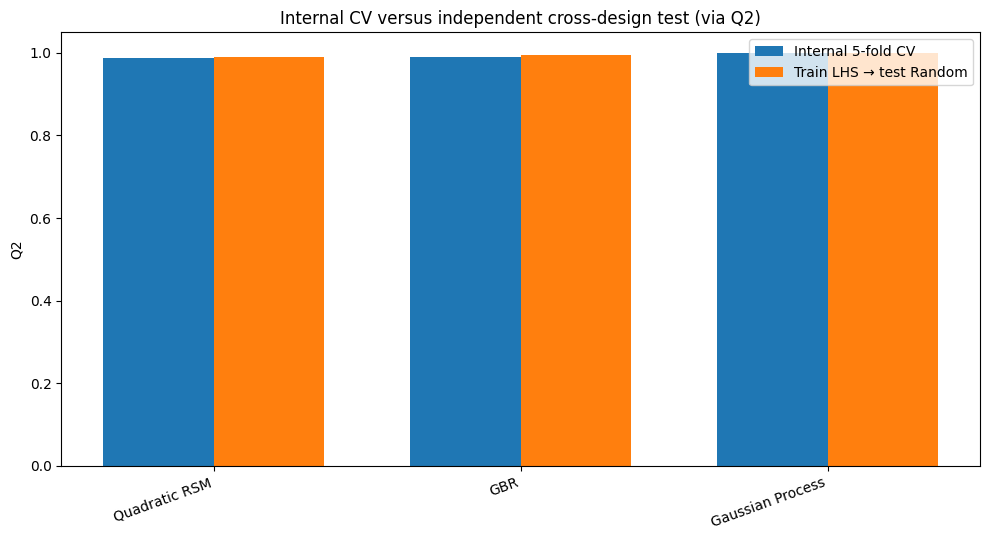

In [68]:

plot_external = external_table[
    external_table["Train design"]=="LHS"
].copy()

x = np.arange(len(plot_external))
width = 0.36

plt.figure(figsize=(10,5.5))
plt.bar(
    x-width/2,
    plot_external["Internal CV Q2"],
    width=width,
    label="Internal 5-fold CV"
)
plt.bar(
    x+width/2,
    plot_external["External Q2"],
    width=width,
    label="Train LHS → test Random"
)
plt.xticks(x, plot_external["Model"], rotation=20, ha="right")
plt.ylabel("Q2")
plt.title("Internal CV versus independent cross-design test (via Q2)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "11_internal_cv_vs_external_test.png", dpi=300)
plt.show()



# Experiment F — Learning curves and simulator budget

Metamodels are introduced because the full simulator is expensive.

A practical validation question is therefore:

> **How much predictive accuracy do we gain by paying for more simulator runs?**

For each \(N\):

1. subsample \(N\) published simulator runs
2. perform 5-fold CV
3. repeat with different subsamples / fold seeds
4. summarize mean and standard deviation of error

We use GBR for this presentation-focused analysis.

In [63]:

SAMPLE_SIZES = [30,50,75,100,150,200,250,300]

def subsample_learning_curve(X, y, design_name, model, sample_sizes, repeats):
    rows = []

    for n in sample_sizes:
        if n > len(y):
            continue

        for rep in range(repeats):
            local_rng = np.random.default_rng(SEED + 1000*rep + n)

            if n == len(y):
                idx = np.arange(len(y))
            else:
                idx = local_rng.choice(len(y), size=n, replace=False)

            Xs = X[idx]
            ys = y[idx]

            splitter = KFold(
                n_splits=5,
                shuffle=True,
                random_state=SEED+rep
            )

            pred, _ = make_oof_predictions(model, Xs, ys, splitter)

            rows.append({
                "Design": design_name,
                "N": n,
                "Repeat": rep,
                "RMSE": rmse(ys,pred),
                "NRMSE": rmse(ys,pred)/(ys.max()-ys.min()),
                "Q2": q2_score(ys,pred),
            })

    return pd.DataFrame(rows)

learn_lhs = subsample_learning_curve(
    X_lhs, y_lhs, "LHS", gbr, SAMPLE_SIZES, N_REPEATS
)
learn_random = subsample_learning_curve(
    X_random, y_random, "Random", gbr, SAMPLE_SIZES, N_REPEATS
)

learning = pd.concat([learn_lhs,learn_random], ignore_index=True)

learning_summary = (
    learning
    .groupby(["Design","N"])
    .agg(
        Mean_RMSE=("RMSE","mean"),
        SD_RMSE=("RMSE","std"),
        Mean_NRMSE=("NRMSE","mean"),
        SD_NRMSE=("NRMSE","std"),
        Mean_Q2=("Q2","mean"),
        SD_Q2=("Q2","std"),
    )
    .reset_index()
)

learning_summary

,Design,N,Mean_RMSE,SD_RMSE,Mean_NRMSE,SD_NRMSE,Mean_Q2,SD_Q2
0,LHS,30,143730.972846,24698.797221,0.075956,0.020470,0.907402,0.051788
1,LHS,50,96899.639381,5616.966163,0.046958,0.001212,0.962393,0.002977
2,LHS,75,86619.440637,5908.876284,0.042369,0.004096,0.969576,0.003714
3,LHS,100,74962.998576,6753.834979,0.036165,0.003697,0.978358,0.004894
4,LHS,150,62405.994545,4054.893629,0.029746,0.002600,0.984531,0.002136
5,LHS,200,58804.898106,2396.295699,0.027343,0.001516,0.986772,0.001805
6,LHS,250,53906.427170,1858.277708,0.024747,0.001058,0.989080,0.000855
7,LHS,300,49555.532424,418.120178,0.022583,0.000191,0.990729,0.000156
8,Random,30,133156.332029,20234.880814,0.069600,0.011003,0.942965,0.015311
9,Random,50,102588.022372,15280.547892,0.049349,0.007410,0.961836,0.012535


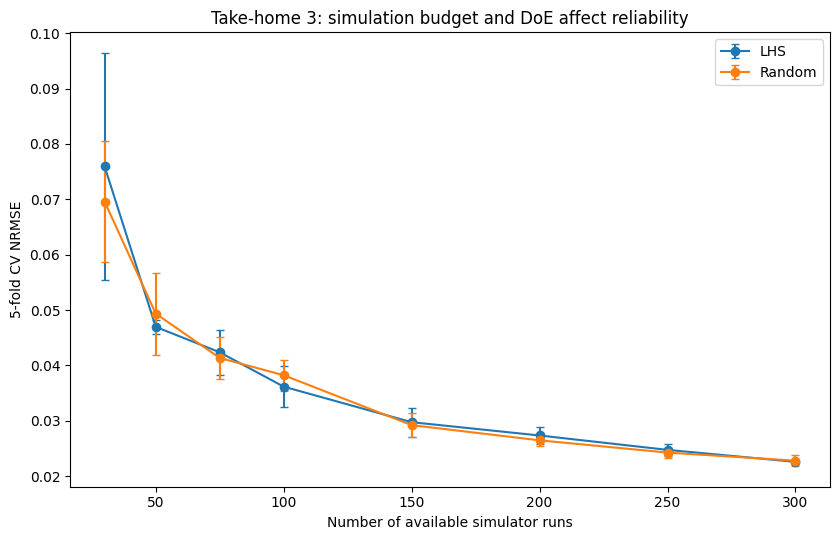

In [64]:

plt.figure(figsize=(8.5,5.5))

for design_name in ["LHS","Random"]:
    d = learning_summary[
        learning_summary["Design"]==design_name
    ].sort_values("N")

    plt.errorbar(
        d["N"],
        d["Mean_NRMSE"],
        yerr=d["SD_NRMSE"].fillna(0),
        marker="o",
        capsize=3,
        label=design_name
    )

plt.xlabel("Number of available simulator runs")
plt.ylabel("5-fold CV NRMSE")
plt.title("Take-home 3: simulation budget and DoE affect reliability")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "12_message3_learning_curve.png", dpi=300)
plt.show()

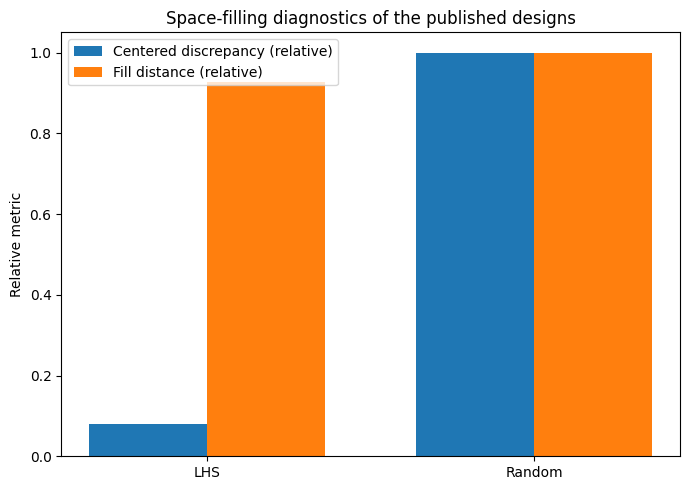

,Design,N,Centered discrepancy,Mean NN distance,95% NN distance,Approx. fill distance
0,LHS,300,0.000045,0.029622,0.057259,0.102479
1,Random,300,0.000557,0.028826,0.056253,0.110493


In [65]:

geo = geometry_table.set_index("Design")

disc = geo["Centered discrepancy"].to_numpy()
fill = geo["Approx. fill distance"].to_numpy()

# Relative scaling is used only for plotting two metrics together.
disc_rel = disc/disc.max()
fill_rel = fill/fill.max()

x = np.arange(len(geo))
width = 0.36

plt.figure(figsize=(7,5))
plt.bar(x-width/2, disc_rel, width=width, label="Centered discrepancy (relative)")
plt.bar(x+width/2, fill_rel, width=width, label="Fill distance (relative)")
plt.xticks(x, geo.index)
plt.ylabel("Relative metric")
plt.title("Space-filling diagnostics of the published designs")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "13_design_geometry_metrics.png", dpi=300)
plt.show()

geometry_table